# Lab 067 · Retrieve locally, then test adaptation

[Lesson](../lessons/0067-local-pfn-retrieval-finetuning.html) · [Reference](../reference/0067-local-pfn-retrieval-finetuning.html) · [Reproduction contract](l067-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** Does retrieving a new context prove that the PFN weights were fine-tuned? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Change the examples and the inference procedure separately

Your goal is to build and distinguish three systems: a global pretrained PFN, the same PFN with a query-specific retrieved context, and a PFN adapted by gradients on local-context episodes. Read [Thomas et al., Sections 2.2–2.4](https://arxiv.org/html/2406.05207v1). Retrieval changes which labeled examples enter the forward pass. Fine-tuning changes neural parameters. One is not evidence that the other happened.

Nearby examples can help an irregular target because a limited context spends fewer slots on irrelevant regions. But locality can also discard useful distant structure, minority classes or rare exceptions. The paper evaluates retrieval and adaptation together and separately; the lesson keeps those ablations explicit rather than promising that nearest neighbors always improve a pretrained model.

## Retrieve in a declared geometry

Fit imputation and scaling on training rows. For query q and candidate row x, squared Euclidean distance is the sum of squared coordinate differences after that transformation. Without scaling, a large-unit feature can dominate the neighborhood for purely numerical reasons. Even standardized Euclidean distance is a modeling choice: it assigns equal weight to coordinates, assumes that numeric proximity is useful and can behave poorly with many irrelevant features.

Select the k smallest distances using a stable tie rule. During training episodes, exclude the query or anchor by original row identity. Excluding only distance zero would wrongly remove distinct duplicate rows; excluding only the first neighbor could retain the anchor under ties. At deployment, candidate labels must also be available at prediction time. Learned retrieval metrics require their own fit/validation boundary.

<div style="overflow-x:auto;max-width:100%">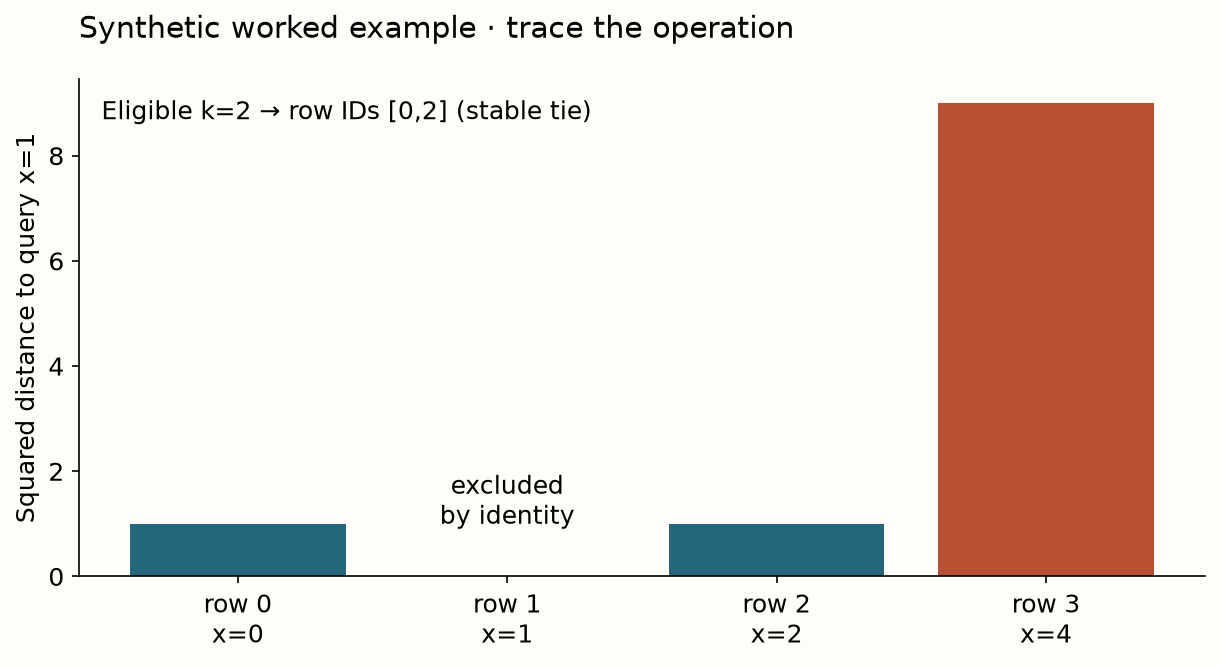</div>

*L067 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Model architecture: retrieval around an actual pretrained PFN

The inference path is training-fitted preprocessing → query-to-memory distances → eligible neighbor IDs → labeled local context plus unlabeled query → pretrained row-token PFN → class probabilities. For the fine-tuned arm, local training episodes update the PFN before the same retrieval inference path is evaluated. The query label appears only in the episode loss or final scoring, never inside its context input.

Our measured local experiment uses the historical v1 checkpoint, 32-neighbor contexts and six gradient steps, with three seeds on three small tasks. Only 24 fixed test rows per task are scored to keep exact-neighbor inference affordable. This deliberately small sample makes uncertainty very weak. It is a real pretrained adaptation experiment, not a reproduction of LoCalPFN's full results. The no-preprocessing gradient path, small budgets and feature geometry are named deviations.

<div style="overflow-x:auto;max-width:100%">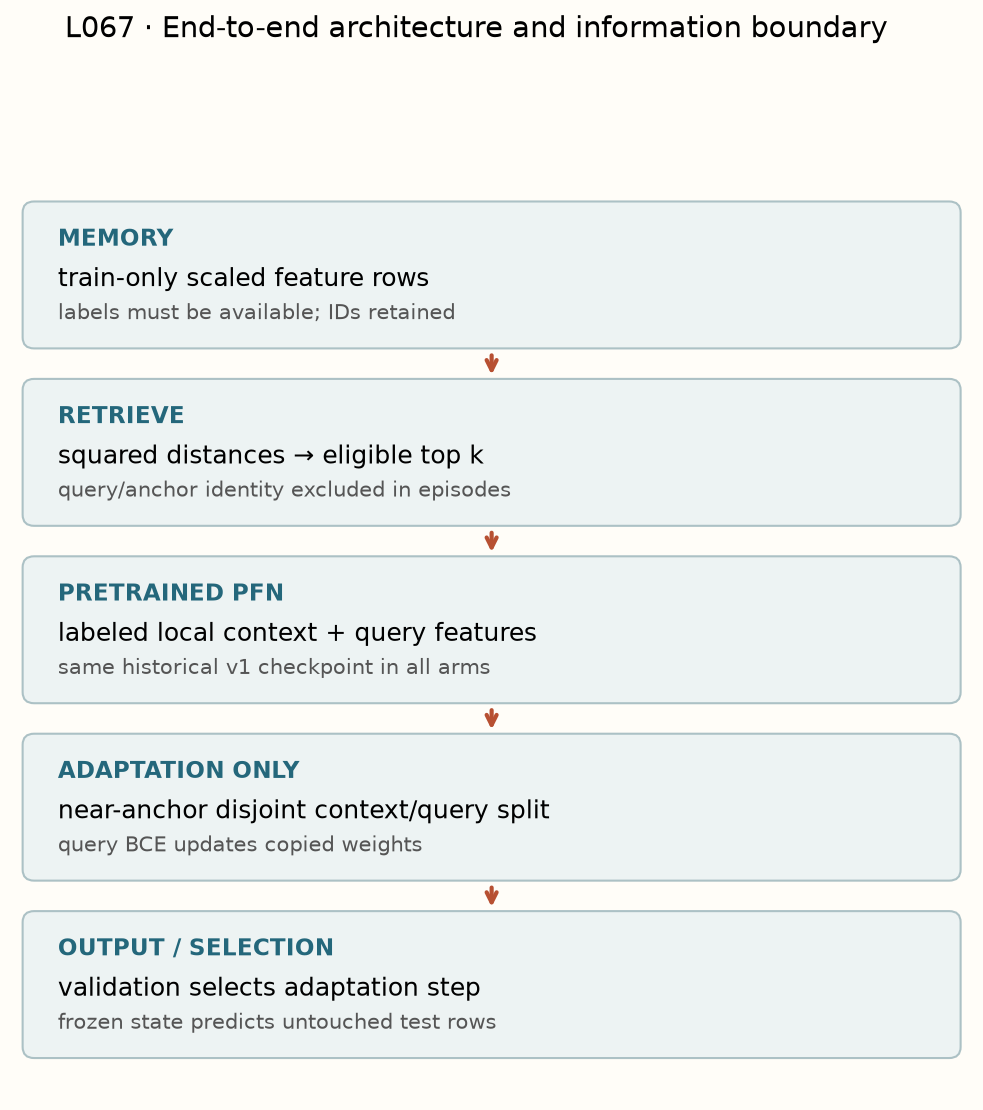</div>

*L067 architecture: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Approximate neighborhoods to share work

If every query uses a different exact neighborhood, the PFN cannot share one context computation across the whole query batch. Retrieval lookup may be cheap while the many forward and backward passes become expensive. The paper's episode construction trades some neighborhood accuracy for shared computation.

Sample an anchor from training data. Retrieve enough nearby rows for a context and several queries, excluding the anchor. Shuffle that neighborhood, then split it into disjoint context and query subsets. All those queries share the context, so one forward pass can train them together. Neighbors of an anchor are not guaranteed to be each other's nearest neighbors; that is the approximation, not a bug. [Section 2.4](https://arxiv.org/html/2406.05207v1#S2.SS4).

Your code must retain the context and query IDs for every episode and assert disjointness. The known query targets supervise the loss after prediction. In the author run, validation selects among adaptation steps; the test set evaluates only the selected state. A nonzero parameter-change check confirms that the adapted arm really updated weights. It does not establish that the update was beneficial.

## Compare failures as carefully as gains

The global and local frozen arms share the same checkpoint and feature treatment. The adapted local arm starts from a copy of those original weights. Copying matters because some historical packages cache model instances globally: mutating one instance can silently change what you thought was the untouched baseline.

A retrieved context can contain only one class. The local runner then uses a declared constant prediction for that context instead of manufacturing missing-class examples from the test set. This boundary should be visible in a production context policy. Expanding k until all classes appear would be another valid, but different, train-label-informed retrieval rule.

<div style="overflow-x:auto;max-width:100%">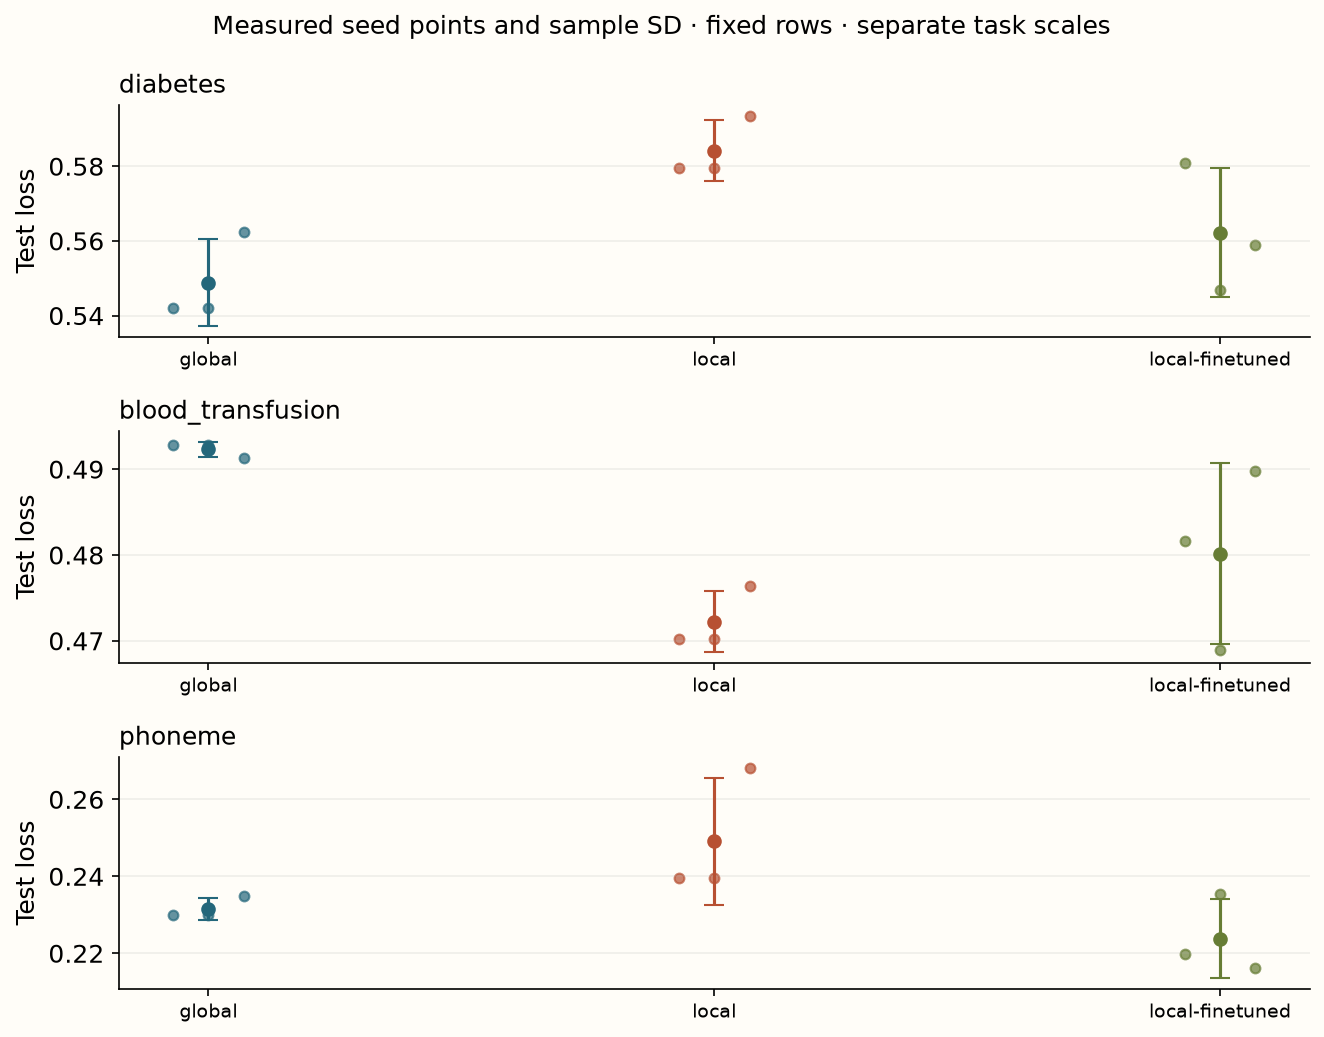</div>

*L067 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

## Exit: show the actual update and its evidence

Submit neighbor IDs, context/query disjointness, episode losses, validation-selected step, checkpoint identity, parameter-change magnitude and paired test scores for all three arms. Explain one case where locality or adaptation failed to help. Do not conclude that six steps and 24 test rows refute or reproduce the paper.

For the relational bridge, replace Euclidean neighbors with a point-in-time relational neighborhood. The same questions survive: which rows and labels were eligible, which computations can be shared, and what exactly was adapted? A graph retrieval mechanism earns credit only after those information and budget boundaries are checked.

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — context_mask; inspect the live function calls
def context_mask(n_context, n_query):
    """Boolean allow-mask: every row reads context; no row reads a query key."""
    if n_context < 1 or n_query < 1:
        raise ValueError('A nonempty context and query are required')
    mask = torch.zeros(n_context + n_query, n_context + n_query, dtype=torch.bool)
    mask[:, :n_context] = True
    return mask

In [ ]:
# PROVIDED — attention; inspect the live function calls
def attention(q, k, v, allowed=None):
    """Scaled dot-product attention; True means allowed (PyTorch SDPA convention)."""
    scores = q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])
    if allowed is not None:
        if not allowed.any(dim=-1).all():
            raise ValueError('Each query needs an allowed key')
        scores = scores.masked_fill(~allowed, float('-inf'))
    return scores.softmax(-1) @ v

In [ ]:
# PROVIDED — AttentionBlock; inspect the live function calls
class AttentionBlock(nn.Module):
    """Pre-normalized multihead attention plus residual feed-forward block."""
    def __init__(self, width, heads):
        super().__init__()
        if width % heads:
            raise ValueError('Width must be divisible by heads')
        self.heads = heads
        self.norm1, self.norm2 = nn.LayerNorm(width), nn.LayerNorm(width)
        self.qkv, self.out = nn.Linear(width, 3*width), nn.Linear(width, width)
        self.ff = nn.Sequential(nn.Linear(width, 2*width), nn.GELU(), nn.Linear(2*width, width))

    def forward(self, x, allowed=None):
        b, n, d = x.shape
        q, k, v = [a.reshape(b,n,self.heads,d//self.heads).transpose(1,2)
                   for a in self.qkv(self.norm1(x)).chunk(3,-1)]
        h = attention(q,k,v,allowed).transpose(1,2).reshape(b,n,d)
        x = x + self.out(h)
        return x + self.ff(self.norm2(x))

In [ ]:
# PROVIDED — RowPFN; inspect the live function calls
class RowPFN(nn.Module):
    """Reduced row-token PFN. Labels are embedded only for context rows.

    Shapes: context [B,C,F], query [B,Q,F], labels [B,C], logits [B,Q,2].
    No positions: simultaneous context row/label permutation leaves predictions fixed.
    """
    def __init__(self, features, width=32, heads=4, layers=2):
        super().__init__()
        self.x_encoder = nn.Linear(features,width)
        self.y_encoder = nn.Embedding(3,width)  # 0,1 plus an explicit unknown symbol
        self.blocks = nn.ModuleList([AttentionBlock(width,heads) for _ in range(layers)])
        self.head = nn.Sequential(nn.LayerNorm(width),nn.Linear(width,2))

    def embeddings(self, context, labels, query):
        c, q = context.shape[1], query.shape[1]
        h = self.x_encoder(torch.cat([context,query],1))
        unknown = torch.full((len(context),q),2,dtype=torch.long,device=context.device)
        h = h + self.y_encoder(torch.cat([labels.long(),unknown],1))
        allow = context_mask(c,q).to(context.device)
        for block in self.blocks:
            h = block(h,allow)
        return h[:,c:]

    def forward(self, context, labels, query):
        return self.head(self.embeddings(context,labels,query))

## TODO 1 · nearest_context

**Goal:** Return stable exact nearest row IDs; handle identity exclusion before selection.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — nearest_context
def nearest_context(train, queries, k, exclude_ids=None):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — nearest_context
memory=np.array([[0.],[1.],[2.],[4.]])
ids=nearest_context(memory,np.array([[1.]]),2,np.array([1]))
assert ids.tolist()==[[0,2]], 'Exclude row identity; preserve deterministic equal-distance order'
duplicates=np.array([[1.],[1.],[2.]])
assert nearest_context(duplicates,duplicates[:1],1,np.array([0])).tolist()==[[1]], 'A distinct duplicate is still eligible'

print("PASS: nearest_context")

## TODO 2 · local_episode

**Goal:** Retrieve around an excluded anchor, shuffle the neighborhood, and return disjoint context/query values, labels and IDs.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 2 — local_episode
def local_episode(x, y, anchor, context_size, query_size, rng):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 2 — local_episode
x=np.arange(40.).reshape(20,2);y=np.arange(20)%2
cx,cy,qx,qy,ci,qi=local_episode(x,y,10,4,3,np.random.default_rng(67))
assert len(ci)==4 and len(qi)==3 and not set(ci)&set(qi)
assert 10 not in ci and 10 not in qi
np.testing.assert_array_equal(cx,x[ci]);np.testing.assert_array_equal(qy,y[qi])

print("PASS: local_episode")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
raw,y,reg,audit=random_task('diabetes',cap=150,seed=67);x=encode_train(raw)
scale=StandardScaler().fit(x['train']);z=scale.transform(x['train']).astype('float32')
torch.manual_seed(67);model=RowPFN(z.shape[1],width=16,heads=2);opt=torch.optim.Adam(model.parameters(),lr=.001)
rng=np.random.default_rng(67);losses=[]
for step in range(12):
    cx,cy,qx,qy,ci,qi=local_episode(z,y['train'],int(rng.integers(len(z))),24,8,rng)
    assert not set(ci)&set(qi)
    loss=nn.functional.cross_entropy(model(torch.tensor(cx)[None],torch.tensor(cy)[None],torch.tensor(qx)[None])[0],torch.tensor(qy))
    opt.zero_grad();loss.backward();opt.step();losses.append(float(loss.detach()))
trial={'episode_losses':losses,'scope':'small from-scratch episode smoke; actual v1 fine-tuning evidence is separate'};print(trial)

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l067_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 67 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':67,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l067_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l067-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l067-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 67 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','67',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l067-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')